In [1]:
# 1. Setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = r"C:\Users\aylin\OneDrive\Desktop\INFO\INFO442\ieee-fraud-detection"
train = pd.read_csv(f"{DATA_DIR}\\train_transaction.csv")

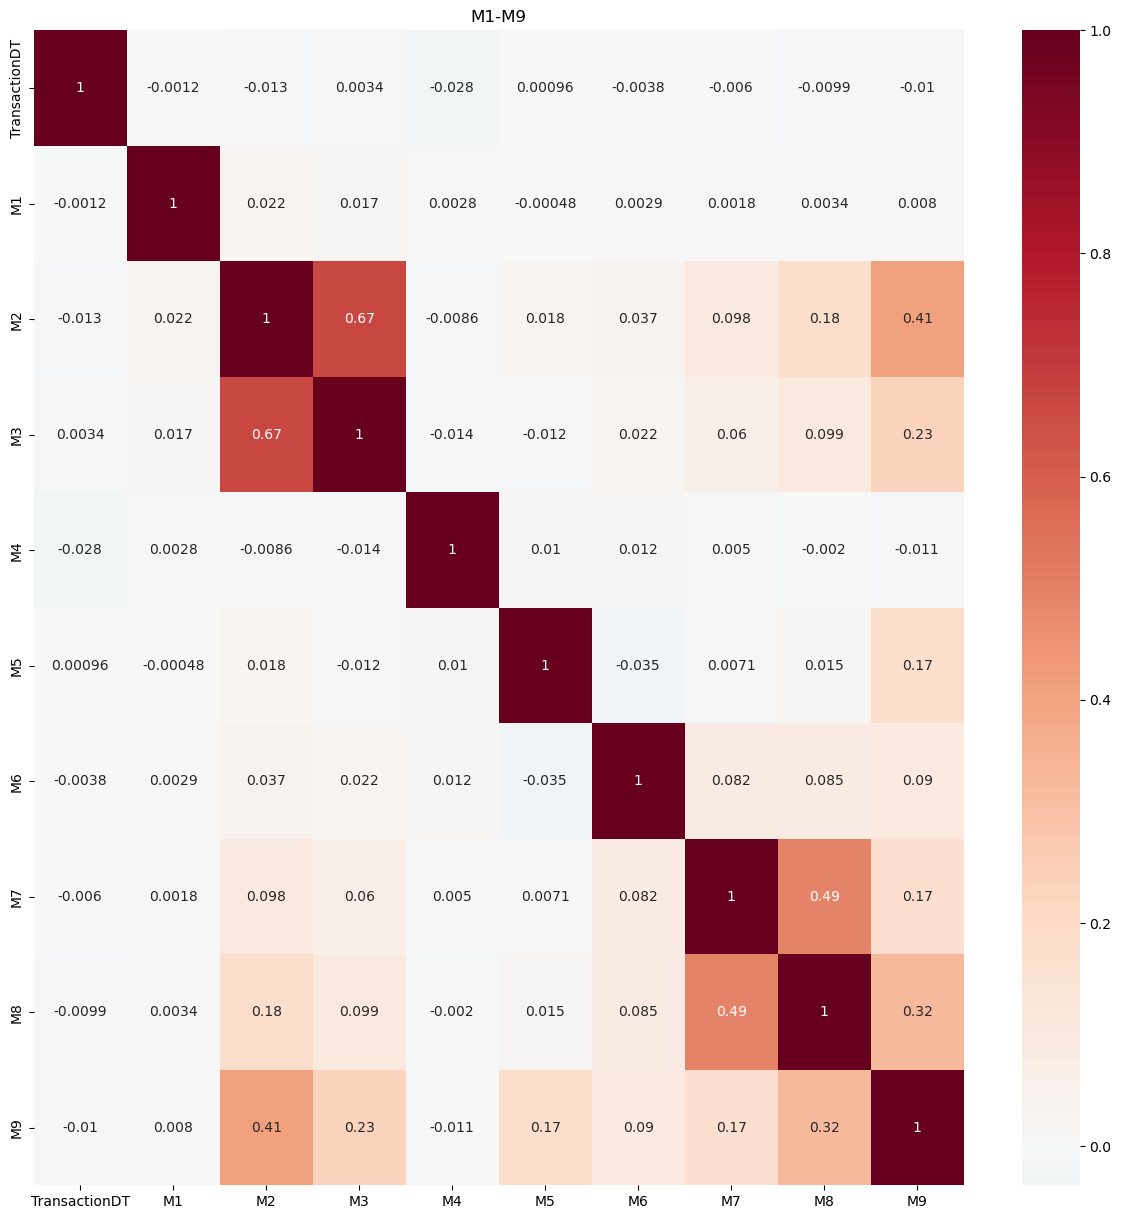

In [2]:
# 2. M Columns
Ms = ['M'+str(x) for x in range(1,10)]
mp = {'F':0,'T':1,'M0':0,'M1':1,'M2':2}
for c in Ms: train[c] = train[c].map(mp)

cols_m = ['TransactionDT'] + Ms
plt.figure(figsize=(15,15))
sns.heatmap(train[cols_m].corr(), cmap='RdBu_r', annot=True, center=0.0)
plt.title('M1-M9')
plt.show()

In [3]:
# 3. M columns correlation check
corr_m = train[cols_m].corr()
high_corr_m = corr_m[(corr_m.abs() > 0.7) & (corr_m != 1.0)]
print(high_corr_m.stack().sort_values(ascending=False))

Series([], dtype: float64)


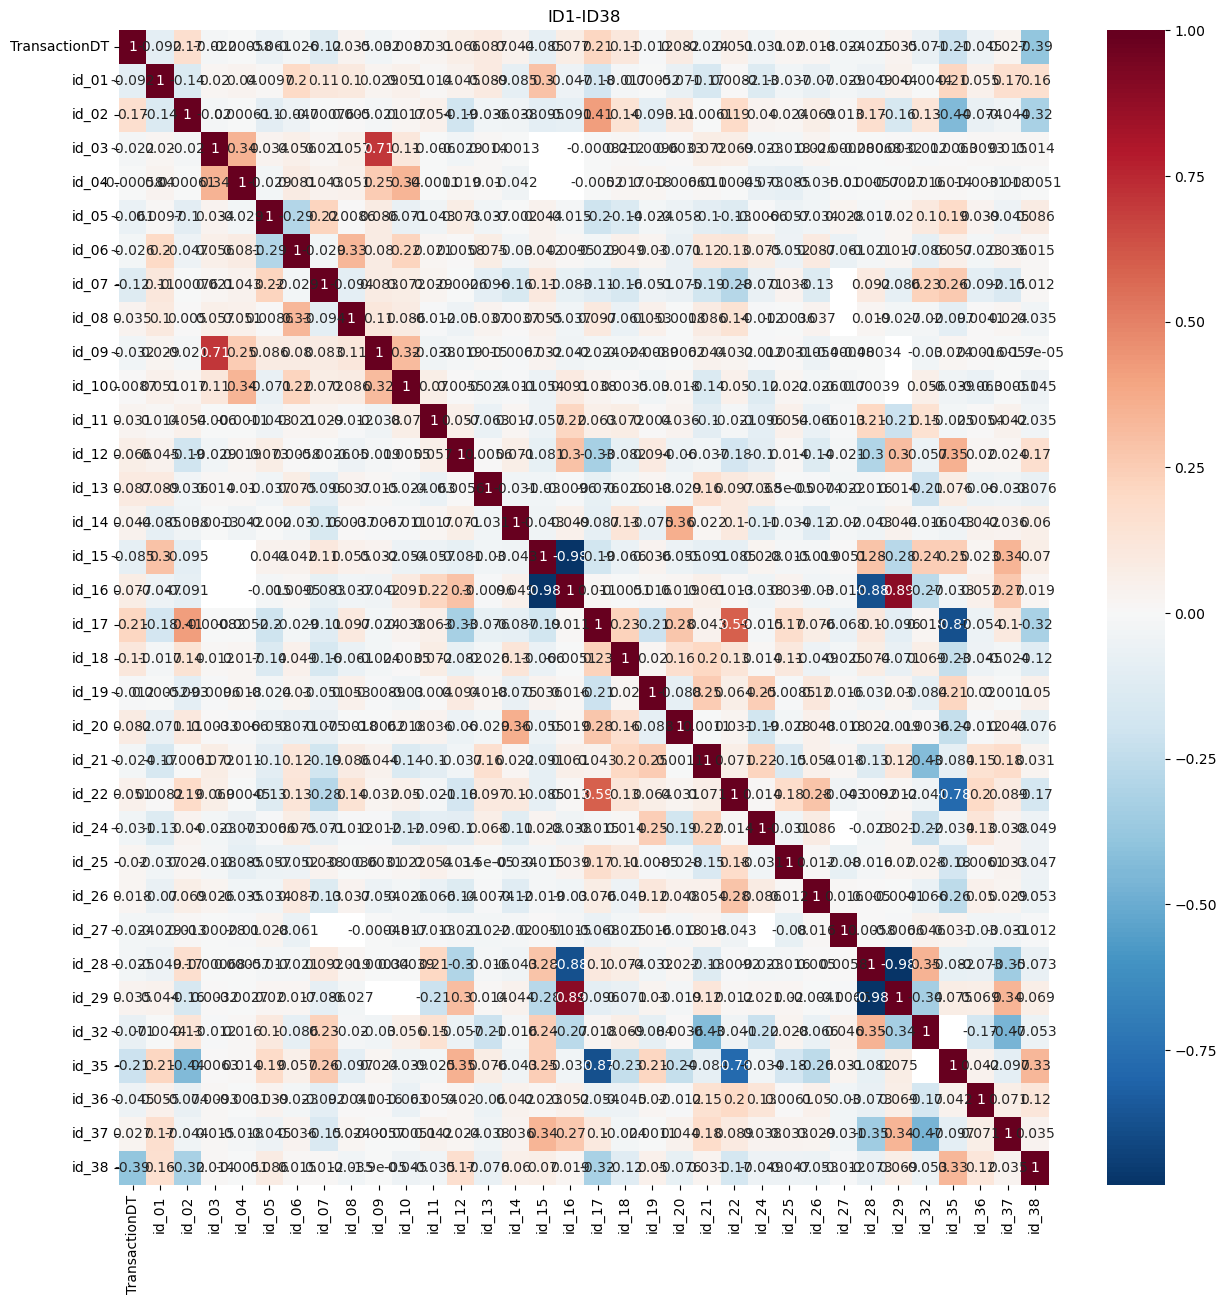

In [4]:
# 4. ID Columns
train_id = pd.read_csv(f"{DATA_DIR}\\train_identity.csv")
train_id = pd.merge(train_id, train[['TransactionID','TransactionDT']], on='TransactionID', how='left')
ids = ['id_0'+str(x) for x in range(1,10)] + ['id_'+str(x) for x in range(10,39)]

booln = ['id_12','id_15','id_16','id_27','id_28','id_29','id_35','id_36','id_37','id_38']
cats = ['id_23','id_30','id_31','id_33','id_34']
mp2 = {'Unknown':0,'NotFound':1,'Found':2,'New':3,'F':0,'T':1}
for c in booln: train_id[c] = train_id[c].map(mp2)

cols_id = ['TransactionDT'] + [x for x in ids if x not in cats]
plt.figure(figsize=(15,15))
sns.heatmap(train_id[cols_id].corr(), cmap='RdBu_r', annot=True, center=0.0)
plt.title('ID1-ID38')
plt.show()

In [5]:
# 5. ID columns correlation check
corr_id = train_id[cols_id].corr()
high_corr_id = corr_id[(corr_id.abs() > 0.7) & (corr_id != 1.0)]
print(high_corr_id.stack().sort_values(ascending=False))

id_16  id_29    0.892353
id_29  id_16    0.892353
id_03  id_09    0.710782
id_09  id_03    0.710782
id_22  id_35   -0.777333
id_35  id_22   -0.777333
id_17  id_35   -0.874551
id_35  id_17   -0.874551
id_16  id_28   -0.876112
id_28  id_16   -0.876112
id_15  id_16   -0.978495
id_16  id_15   -0.978495
id_28  id_29   -0.981518
id_29  id_28   -0.981518
dtype: float64
